# 이질적 처치 효과(HTE)

게임에 어떤 처치를 시행했을 때, 모든 유저에게 같은 효과가 나타날까요?

직관적으로 그렇지 않습니다. 매일 접속하는 헤비 유저와 가끔 접속하는 라이트 유저는 같은 처치에 다르게 반응할 수 있습니다.

이처럼 처치 효과가 개인마다 다른 현상을 HTE(Heterogeneous Treatment Effects, 이질적 처치 효과)라고 합니다.

## 반사실 문제와 처치 효과

개인별 처치 효과(ITE)는 처치를 받은 경우와 받지 않은 경우의 결과 차이입니다.

```
ITE_i = Y_i(1) - Y_i(0)
```

문제는 같은 유저를 두 상태에서 동시에 관찰할 수 없다는 점입니다. 이것이 반사실(counterfactual) 문제입니다.

| 유저 | 처치 여부 | Y(1) 처치 시 | Y(0) 미처치 시 | ITE |
|------|-----------|------------|--------------|-----|
| 유저 A | 처치 받음 | 관찰 가능 ✓ | 관찰 불가 ✗ | 계산 불가 |
| 유저 B | 처치 안 받음 | 관찰 불가 ✗ | 관찰 가능 ✓ | 계산 불가 |

그래서 집단 평균인 ATE를 추정합니다.

```
ATE = E[Y(1) - Y(0)]
```

그런데 ATE는 이질성을 숨깁니다. 유저마다 처치 효과가 달라도 평균이 이를 가려버립니다.

이 차이를 분석하는 것이 HTE이고, 특성 X를 조건으로 수치화한 것이 CATE입니다.

```
CATE(X) = E[Y(1) - Y(0) | X]
```

| 개념 | 정의 | 비고 |
|------|------|------|
| ITE | 개인 처치 효과 | 반사실 문제로 직접 관측 불가 |
| ATE | ITE의 전체 평균 | 이질성을 무시 |
| HTE | ITE가 개인마다 다른 현상 | ATE가 숨기는 것 |
| CATE | 특성 X별 ITE 평균 | HTE를 수치화하는 도구 |

## 실험 설계

어느 게임 회사가 2022년 6월 25일 특정 처치를 시행했습니다.

| 구간 | 기간 | 의미 |
|------|------|------|
| T=0 | 2022-06-18 ~ 06-25 | 처치 직전 7일 |
| T=1 | 2022-06-25 ~ 07-02 | 처치 직후 7일 |

처치를 받지 않은 통제군이 따로 없어, 처치 1주일 전 기간을 가짜 통제군(pseudo-control)으로 사용합니다. 요일 구성이 동일하여 요일 효과를 통제합니다.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

BASE = Path('backend-ts_v0.1/GAME_C_JUL')
CACHE = Path('features_game_c_jul.parquet')

In [44]:
def extract_features(filepath):
    df = pd.read_parquet(filepath)
    if len(df) == 0:
        return None
    return {
        'n_logins': int((df['action'] == 1).sum()),
        'n_get': int((df['action'] == 2).sum()),
        'n_post': int((df['action'] == 3).sum()),
        'n_put': int((df['action'] == 4).sum()),
        'n_actions': len(df),
        'n_days': int(df['timestamp'].dt.date.nunique()),
    }

if CACHE.exists():
    data = pd.read_parquet(CACHE)
else:
    with open(BASE / 'info.json', encoding='utf-8') as f:
        info = json.load(f)
    records = []
    for item in info:
        fp = BASE / item['X']
        if not fp.exists():
            continue
        feats = extract_features(fp)
        if feats is None:
            continue
        feats.update({'T': item['T'], 'Y0': item['Y'][0], 'Y1': item['Y'][1], 'Y2': item['Y'][2]})
        records.append(feats)
    data = pd.DataFrame(records)
    data.to_parquet(CACHE, index=False)

## 1단계 — ATE: 전체 평균 처치 효과

처치 전후 재방문율을 비교합니다.

```
ATE = E[Y | T=1] - E[Y | T=0]
```

T=0 재방문율: 55.7%
T=1 재방문율: 57.9%
ATE: +2.2%


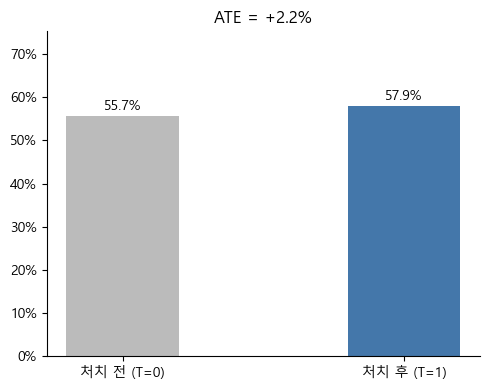

In [41]:
rate_t0 = data.loc[data['T'] == 0, 'Y2'].mean()
rate_t1 = data.loc[data['T'] == 1, 'Y2'].mean()
ate = rate_t1 - rate_t0

print(f'T=0 재방문율: {rate_t0:.1%}')
print(f'T=1 재방문율: {rate_t1:.1%}')
print(f'ATE: {ate:+.1%}')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['처치 전 (T=0)', '처치 후 (T=1)'], [rate_t0, rate_t1],
       color=['#BBBBBB', '#4477AA'], width=0.4)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0, max(rate_t0, rate_t1) * 1.3)
for i, v in enumerate([rate_t0, rate_t1]):
    ax.text(i, v + 0.008, f'{v:.1%}', ha='center', va='bottom')
ax.set_title(f'ATE = {ate:+.1%}')
plt.tight_layout()
plt.show()

## 2단계 — HTE: 효과는 모든 유저에게 같았을까?

ATE는 전체 평균입니다. 처치 효과가 유저마다 다르다면 평균이 그 차이를 숨깁니다.

유저를 특성에 따라 그룹으로 나눠 처치 효과를 비교하는 것을 sub-group analysis라고 합니다.

접속 횟수 중앙값을 기준으로 라이트/코어 유저로 나눠 각 그룹의 처치 효과를 비교합니다.

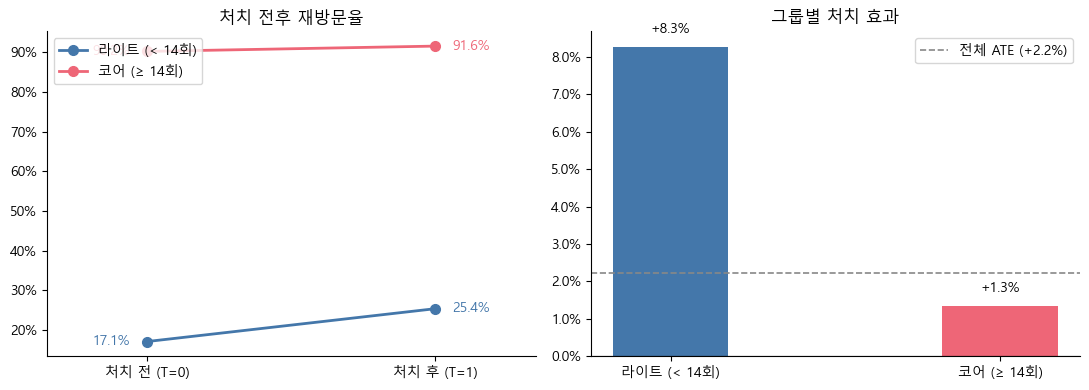

In [ ]:
median_logins = data['n_logins'].median()
groups = {
    f'라이트 (< {int(median_logins)}회)': data[data['n_logins'] < median_logins],
    f'코어 (≥ {int(median_logins)}회)': data[data['n_logins'] >= median_logins],
}

stats = {
    label: {'T0': g[g['T'] == 0]['Y2'].mean(), 'T1': g[g['T'] == 1]['Y2'].mean()}
    for label, g in groups.items()
}
for s in stats.values():
    s['effect'] = s['T1'] - s['T0']

COLORS = ['#4477AA', '#EE6677']
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
for i, (label, s) in enumerate(stats.items()):
    ax.plot([0, 1], [s['T0'], s['T1']], color=COLORS[i], marker='o',
            linewidth=2, markersize=7, label=label)
    ax.text(-0.06, s['T0'], f'{s["T0"]:.1%}', ha='right', va='center', color=COLORS[i])
    ax.text(1.06, s['T1'], f'{s["T1"]:.1%}', ha='left', va='center', color=COLORS[i])
ax.set_xticks([0, 1])
ax.set_xticklabels(['처치 전 (T=0)', '처치 후 (T=1)'])
ax.set_xlim(-0.35, 1.35)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('처치 전후 재방문율')
ax.legend(loc='upper left')

ax = axes[1]
labels = list(stats.keys())
effects = [s['effect'] for s in stats.values()]
ax.bar(labels, effects, color=COLORS, width=0.35)
ax.axhline(ate, color='#888888', linestyle='--', linewidth=1.2, label=f'전체 ATE ({ate:+.1%})')
ax.axhline(0, color='black', linewidth=0.8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('그룹별 처치 효과')
for i, v in enumerate(effects):
    offset, va = (0.003, 'bottom') if v >= 0 else (-0.003, 'top')
    ax.text(i, v + offset, f'{v:+.1%}', ha='center', va=va)
ax.legend()

plt.tight_layout()
plt.show()

## 3단계 — CATE: HTE를 연속적으로 수치화하기

그룹 비교로는 "두 그룹이 다르다"는 것만 알 수 있습니다.
상호작용 모델을 사용하면 특성 X에 따라 처치 효과가 어떻게 달라지는지 연속적으로 추정할 수 있습니다.

```
Y = β₀ + β₁T + β₂X + β₃(T×X) + ε

CATE(X) = ∂Ŷ/∂T = β₁ + β₃·X
```

β₁은 X와 무관한 기본 처치 효과이고, β₃는 X가 1 증가할 때 처치 효과가 변하는 크기입니다.

| β₃의 부호 | 의미 |
|-----------|------|
| β₃ > 0 | X가 클수록 처치 효과 증가 |
| β₃ < 0 | X가 클수록 처치 효과 감소 |
| β₃ ≈ 0 | HTE 없음 — ATE로 충분 |

In [43]:
from numpy.linalg import lstsq

X_var = 'n_logins'
model_data = data[['T', X_var, 'Y2']].dropna().copy()
model_data['T_x_X'] = model_data['T'] * model_data[X_var]

X_mat = np.column_stack([
    np.ones(len(model_data)), model_data['T'], model_data[X_var], model_data['T_x_X']
])
coef, _, _, _ = lstsq(X_mat, model_data['Y2'].values, rcond=None)
beta0, beta_T, beta_X, beta_TX = coef

print(f'β₁ (기본 처치 효과): {beta_T:+.4f}')
print(f'β₃ (접속 횟수당 효과 변화): {beta_TX:+.6f}')
print()

for pct, label in [(0.05, 'p5 '), (0.50, '중앙'), (0.95, 'p95')]:
    x_val = int(model_data[X_var].quantile(pct))
    print(f'접속 {x_val:2d}회 ({label}): CATE = {beta_T + beta_TX * x_val:+.1%}')

model_data['cate'] = beta_T + beta_TX * model_data[X_var]

β₁ (기본 처치 효과): +0.1679
β₃ (접속 횟수당 효과 변화): -0.009004

접속  1회 (p5 ): CATE = +15.9%
접속 14회 (중앙): CATE = +4.2%
접속 31회 (p95): CATE = -11.1%


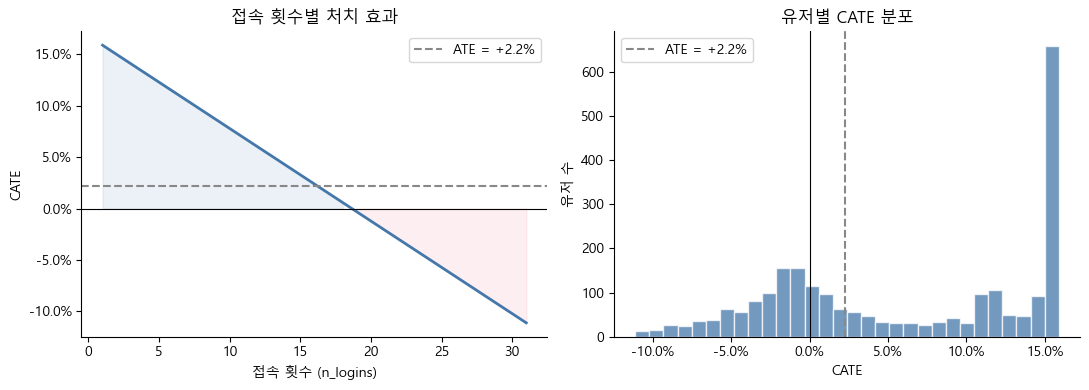

In [39]:
x_min = int(model_data[X_var].quantile(0.05))
x_max = int(model_data[X_var].quantile(0.95))
x_range = np.arange(x_min, x_max + 1)
cate_line = beta_T + beta_TX * x_range

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(x_range, cate_line, color='#4477AA', linewidth=2)
ax.axhline(ate, color='#888888', linestyle='--', label=f'ATE = {ate:+.1%}')
ax.axhline(0, color='black', linewidth=0.8)
ax.fill_between(x_range, cate_line, 0,
                where=(cate_line > 0), alpha=0.1, color='#4477AA')
ax.fill_between(x_range, cate_line, 0,
                where=(cate_line <= 0), alpha=0.1, color='#EE6677')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel('접속 횟수 (n_logins)')
ax.set_ylabel('CATE')
ax.set_title('접속 횟수별 처치 효과')
ax.legend()

ax = axes[1]
plot_data = model_data.loc[model_data[X_var] <= x_max, 'cate']
ax.hist(plot_data, bins=30, color='#4477AA', alpha=0.75, edgecolor='white')
ax.axvline(ate, color='#888888', linestyle='--', label=f'ATE = {ate:+.1%}')
ax.axvline(0, color='black', linewidth=0.8)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel('CATE')
ax.set_ylabel('유저 수')
ax.set_title('유저별 CATE 분포')
ax.legend()

plt.tight_layout()
plt.show()

## 정리

| 개념 | 핵심 질문 |
|------|----------|
| ATE | 처치가 전반적으로 효과 있는가? |
| HTE | 처치 효과가 개체마다 다른가? |
| CATE | 특성 X를 가진 유저에게 얼마나 효과적인가? |

1. ATE: 처치 후 전체 재방문율이 소폭 상승
2. HTE: 라이트 유저와 코어 유저의 처치 효과가 다름 (sub-group analysis)
3. CATE: 접속 횟수가 많을수록 처치 효과 감소 (β₃ < 0, 상호작용 모델)